# ML-ZOOMCAMP WEEKK02 -HOMEWORK02

# import packages

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('max_colwidth', 1000)
pd.set_option("display.precision", 20)

# load data

In [3]:
path="https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"

In [4]:
dataset = pd.read_csv(path)

In [5]:
dataset.head(5)

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.43375860621881656698,17.69999999999999928946,2003,Europe,Gasoline,All-wheel drive,0.0,13.23172890624141118110
1,130,5.0,97.0,3149.66493422003577506985,17.80000000000000071054,2007,USA,Gasoline,Front-wheel drive,0.0,13.68821743546379288148
2,170,NaN,78.0,3079.03899736883977311663,15.09999999999999964473,2018,Europe,Gasoline,Front-wheel drive,0.0,14.24634099816086596491
3,220,4.0,NaN,2542.39240182837784232106,20.19999999999999928946,2009,USA,Diesel,All-wheel drive,2.0,16.91273559598635145562
4,210,1.0,140.0,3460.87098998901819868479,14.40000000000000035527,2009,Europe,Gasoline,All-wheel drive,2.0,12.48836912196456161439


The goal of this homework is to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg').

<b> Preparing the dataset </b> 
<br>
<br>
Use only the following columns:
<br>
<br>

* 'engine_displacement',
* 'horsepower',
* 'vehicle_weight',
* 'model_year',
* 'fuel_efficiency_mpg'

<br>
<br>

<b> EDA </b> 
<br>
<br>
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

In [6]:
df=dataset[['engine_displacement','horsepower', 'vehicle_weight','model_year','fuel_efficiency_mpg']]
df.head(5)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.43375860621881656698,2003,13.23172890624141118110
1,130,97.0,3149.66493422003577506985,2007,13.68821743546379288148
2,170,78.0,3079.03899736883977311663,2018,14.24634099816086596491
3,220,NaN,2542.39240182837784232106,2009,16.91273559598635145562
4,210,140.0,3460.87098998901819868479,2009,12.48836912196456161439


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


<Axes: >

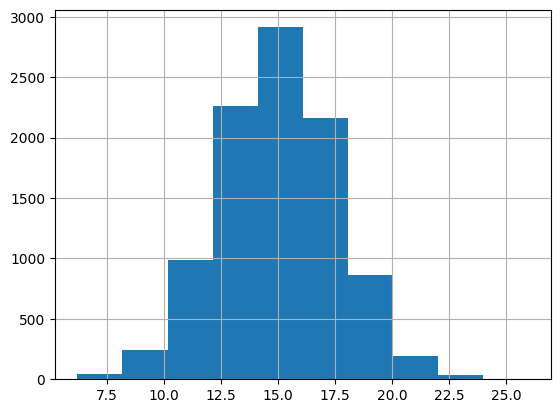

In [8]:
df.fuel_efficiency_mpg.hist()

In [9]:
df.shape

(9704, 5)

In [10]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [11]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.00000000000000000000,8996.00000000000000000000,9704.00000000000000000000,9704.00000000000000000000,9704.00000000000000000000
mean,199.70836768342951472732,149.65729212983546858595,3001.28099337313551586703,2011.48402720527610654244,14.98524322820857257454
std,49.45531899386478613678,29.87955520033934320168,497.89486003118440748949,6.65980762782058288707,2.55646770289742830684
min,10.00000000000000000000,37.00000000000000000000,952.68176064364956801001,2000.00000000000000000000,6.20097053339281512052
25%,170.00000000000000000000,130.00000000000000000000,2666.24898483263450543745,2006.00000000000000000000,13.26745863717417428518
50%,200.00000000000000000000,149.00000000000000000000,2993.22629616921631168225,2012.00000000000000000000,15.00603696348121118831
75%,230.00000000000000000000,170.00000000000000000000,3334.95703919693960415316,2017.00000000000000000000,16.70796530682678593394
max,380.00000000000000000000,271.00000000000000000000,4739.07708939209896925604,2023.00000000000000000000,25.96722204888371976494


<Axes: >

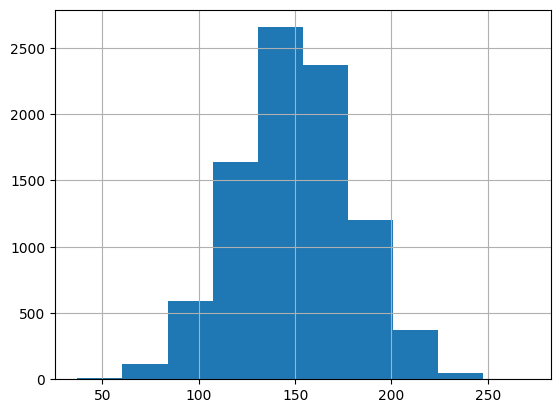

In [12]:
df.horsepower.hist()

In [13]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

print("n_val:", n_val)
print("n_test:", n_test)
print("n_train:", n_train)
print("n_total:", n_val+n_test+n_train)


n_val: 1940
n_test: 1940
n_train: 5824
n_total: 9704


In [14]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

In [15]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [16]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test =df_test.fuel_efficiency_mpg.values

In [17]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

len(y_train)

5824

## Question 3

In [18]:
def prepare_X(df,fill=0):
    dataframe=df.copy()
    dataframe.horsepower = dataframe.horsepower.fillna(value=fill)
    X = dataframe.values
    return X

In [19]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [20]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    rmse=round(np.sqrt(mse), 2)
    return rmse

In [21]:
df_train.describe()

,engine_displacement,horsepower,vehicle_weight,model_year
count,5824.00000000000000000000,5395.00000000000000000000,5824.00000000000000000000,5824.00000000000000000000
mean,199.42994505494505119714,149.54476367006486725586,3006.67291918901310054935,2011.44471153846143351984
std,49.54317745860576138739,29.61049810443747887234,497.85699759647906148530,6.66919319867408688651
min,10.00000000000000000000,46.00000000000000000000,952.68176064364956801001,2000.00000000000000000000
25%,170.00000000000000000000,129.00000000000000000000,2669.31337434474971814780,2006.00000000000000000000
50%,200.00000000000000000000,149.00000000000000000000,2993.34828332194365430041,2011.00000000000000000000
75%,230.00000000000000000000,170.00000000000000000000,3342.15151982880161085632,2017.00000000000000000000
max,380.00000000000000000000,246.00000000000000000000,4610.97322862309738411568,2023.00000000000000000000


In [22]:
mean_horsepower_train=df_train.horsepower.mean()
mean_horsepower_val=df_val.horsepower.mean()
print(mean_horsepower_train)
print(mean_horsepower_val)

149.54476367006487
150.03270509977827


In [23]:
fill_train_value=[0,mean_horsepower_train]
fill_train_value2=["con cero","mean_horsepower_train"]

fill_val_value=[0,mean_horsepower_train, mean_horsepower_val]
fill_val_value2=["con cero","mean_horsepower_train", "mean_horsepower_val"]


name_rmse=[]
list_rmse=[]

indice=0

for i in range(0, len(fill_train_value)):
    X_train = prepare_X(df_train, fill=fill_train_value[i])
    w0, w = train_linear_regression(X_train, y_train)

    
    for j in range(0, len(fill_val_value)):
                
        X_val =  prepare_X(df_val, fill=fill_val_value[j])
        
        y_pred = w0 + X_val.dot(w)
        name_rmse.append("fill_train= "+fill_train_value2[i]+" "+str(round(fill_train_value[i],4))+" filla_val="+fill_val_value2[j]+" "+str(round(fill_val_value[j],4)))
        list_rmse.append(rmse(y_val, y_pred))




In [24]:
res = pd.DataFrame(list(zip(name_rmse, list_rmse)),
               columns =['name_rmse', 'rmse'])

res

,name_rmse,rmse
0,fill_train= con cero 0 filla_val=con cero 0,0.52000000000000001776
1,fill_train= con cero 0 filla_val=mean_horsepower_train 149.5448,0.50000000000000000000
2,fill_train= con cero 0 filla_val=mean_horsepower_val 150.0327,0.50000000000000000000
3,fill_train= mean_horsepower_train 149.5448 filla_val=con cero 0,0.60999999999999998668
4,fill_train= mean_horsepower_train 149.5448 filla_val=mean_horsepower_train 149.5448,0.46000000000000001998
5,fill_train= mean_horsepower_train 149.5448 filla_val=mean_horsepower_val 150.0327,0.46000000000000001998


## Question 4

In [32]:
rr=[0, 0.01, 0.1, 1, 5, 10, 100]

list_rmse_r=[]
list_rmse_r_round=[]

In [26]:
def prepare_X(df,fill=0):
    dataframe=df.copy()
    dataframe.horsepower = dataframe.horsepower.fillna(value=fill)
    X = dataframe.values
    return X

In [27]:
def train_linear_regression_reg(X, y, r=0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [28]:
def rmse(y, y_pred,rounded=2):
    se = (y - y_pred) ** 2
    mse = se.mean()
    rmse=round(np.sqrt(mse),rounded)
    return rmse

In [33]:
for i in range(0,len(rr)):
    X_train = prepare_X(df_train, fill=0)
    #print(rr[i])
    w0, w = train_linear_regression_reg(X_train, y_train,r=rr[i])

    X_val =  prepare_X(df_val, fill=0)
        
    y_pred = w0 + X_val.dot(w)
    
    list_rmse_r.append(rmse(y_val, y_pred, rounded=20))
    list_rmse_r_round.append(rmse(y_val, y_pred, rounded=2))

    

In [34]:
res2= pd.DataFrame(list(zip(rr, list_rmse_r, list_rmse_r_round)),
               columns =['r', 'rmse_r', 'rmse_r_round'])

res2

,r,rmse_r,rmse_r_round
0,0.00000000000000000000,0.51737826388411845002,0.52000000000000001776
1,0.01000000000000000021,0.51711155257755592185,0.52000000000000001776
2,0.10000000000000000555,0.51875251307016290170,0.52000000000000001776
3,1.00000000000000000000,0.52223488020925279418,0.52000000000000001776
4,5.00000000000000000000,0.52289160928234545977,0.52000000000000001776
5,10.00000000000000000000,0.52298129796365688815,0.52000000000000001776
6,100.00000000000000000000,0.52306362338199263728,0.52000000000000001776


## Question 5

In [35]:
seed=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

list_rmse_seed=[]

In [36]:
def prepare_X(df,fill=0):
    dataframe=df.copy()
    dataframe.horsepower = dataframe.horsepower.fillna(value=fill)
    X = dataframe.values
    return X

In [37]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [38]:
def rmse(y, y_pred,rounded=2):
    se = (y - y_pred) ** 2
    mse = se.mean()
    rmse=np.sqrt(mse)
    return rmse

In [39]:
for i in range(0,len(seed)):

    
    idx = np.arange(n)
    np.random.seed(seed[i])
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    #len(df_train), len(df_val), len(df_test)
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test =df_test.fuel_efficiency_mpg.values
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    
    #len(y_train)

    
    X_train = prepare_X(df_train, fill=0)
    #print(rr[i])
    w0, w = train_linear_regression(X_train, y_train)

    X_val =  prepare_X(df_val, fill=0)
        
    y_pred = w0 + X_val.dot(w)
    
    list_rmse_seed.append(rmse(y_val, y_pred))

In [40]:
res3= pd.DataFrame(list(zip(seed, list_rmse_seed)),
               columns =['seed', 'list_rmse_seed'])

res3

,seed,list_rmse_seed
0,0,0.52065312962972065680
1,1,0.52133889128665056312
2,2,0.52280699749136660959
3,3,0.51595167412554909792
4,4,0.51091294601169368050
5,5,0.52834064602129349186
6,6,0.53139106581903727822
7,7,0.50906703873903802471
8,8,0.51473991294827892151
9,9,0.51318659082926898485


In [41]:
round(np.std(res3.list_rmse_seed),3)

np.float64(0.007)

## question 6

In [42]:
idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

#len(df_train), len(df_val), len(df_test)

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)



y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test =df_test.fuel_efficiency_mpg.values
y_full_train =df_full_train.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_full_train['fuel_efficiency_mpg']

#len(y_train)

In [43]:
def prepare_X(df,fill=0):
    dataframe=df.copy()
    dataframe.horsepower = dataframe.horsepower.fillna(value=fill)
    X = dataframe.values
    return X

In [44]:
def train_linear_regression_reg(X, y, r=0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [45]:
def rmse(y, y_pred,rounded=2):
    se = (y - y_pred) ** 2
    mse = se.mean()
    rmse=np.sqrt(mse)
    return rmse

In [46]:
X_full_train = prepare_X(df_full_train, fill=0)

w0, w = train_linear_regression_reg(X_full_train, y_full_train,r=0.001)

X_test =  prepare_X(df_test, fill=0)
    
y_pred = w0 + X_test.dot(w)

rmse(y_test, y_pred)

np.float64(0.5156261299185628)